In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

# Para plantear el modelo lineal
from formulaic import Formula   

# Herramientas de modelos lineales
from sklearn import linear_model  

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error  

## 1

In [2]:
def coefs_r1(x, y):
    beta_1 = np.sum((x - x.mean())*(y - y.mean()))/np.sum((x - x.mean())**2)
    beta_0 = y.mean() - beta_1 * x.mean()
    return beta_1, beta_0

### b

In [3]:
gapminder = pd.read_csv('gapminder.csv')
gap_arg = gapminder[gapminder['country'] == 'Argentina']

print(coefs_r1(gap_arg['year'], gap_arg['lifeExp']))


(np.float64(0.2317083916083916), np.float64(-389.6063445221445))


In [4]:
y, X = Formula('lifeExp ~ year').get_model_matrix(gap_arg)
modelo = linear_model.LinearRegression(fit_intercept= False)
modelo.fit(X, y)

beta = modelo.coef_
beta_1 = beta[0][0]
beta_0 = beta[0][1]
print(beta_1 , beta_0)

-389.6063445221505 0.23170839160839457


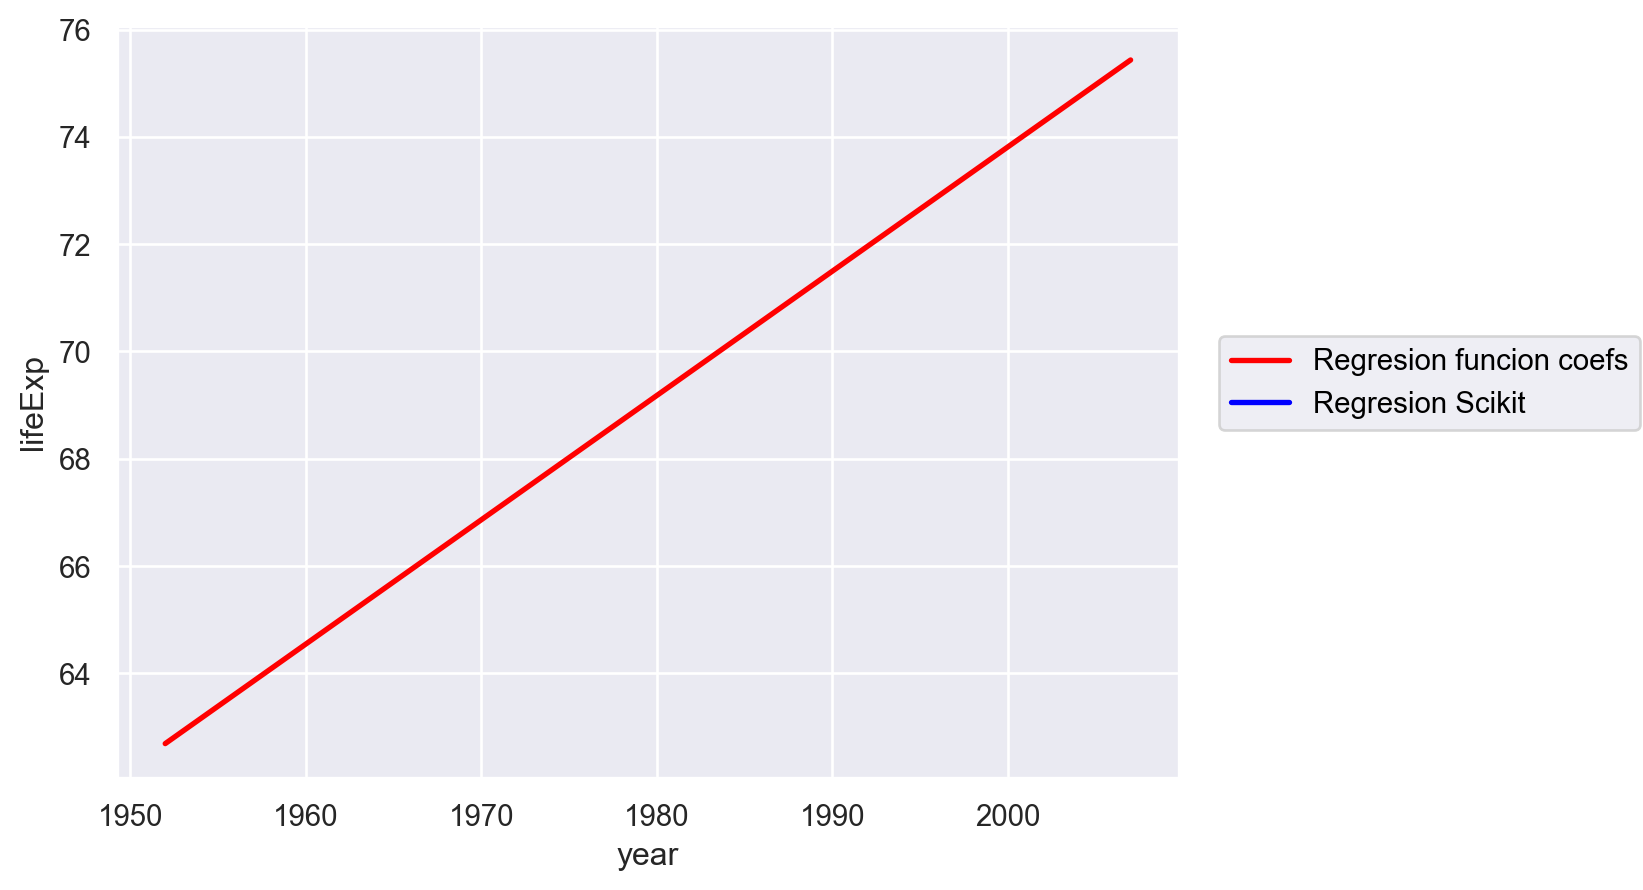

In [5]:
y_pred = modelo.predict(X)

(
    so.Plot(
        data= gap_arg,
        x = 'year',
        y = 'lifeExp'
    )
    .add(
        so.Line(color = 'red', linewidth= 2),
        so.PolyFit(1),
        label = 'Regresion funcion coefs'
    )
    .add(
        so.Line(color = 'blue', linewidth= 2),
        y = y_pred.flatten(),
        label = 'Regresion Scikit'
    )
)

## 2

In [6]:
datos = pd.read_csv('inmuebles.csv')
datos.head()

,superficie,precio,zona
0,110.0,454.425690,Zona 2
1,109.0,383.004114,Zona 2
2,101.0,437.362638,Zona 2
3,58.0,304.392486,Zona 3
4,129.0,620.027722,Zona 3


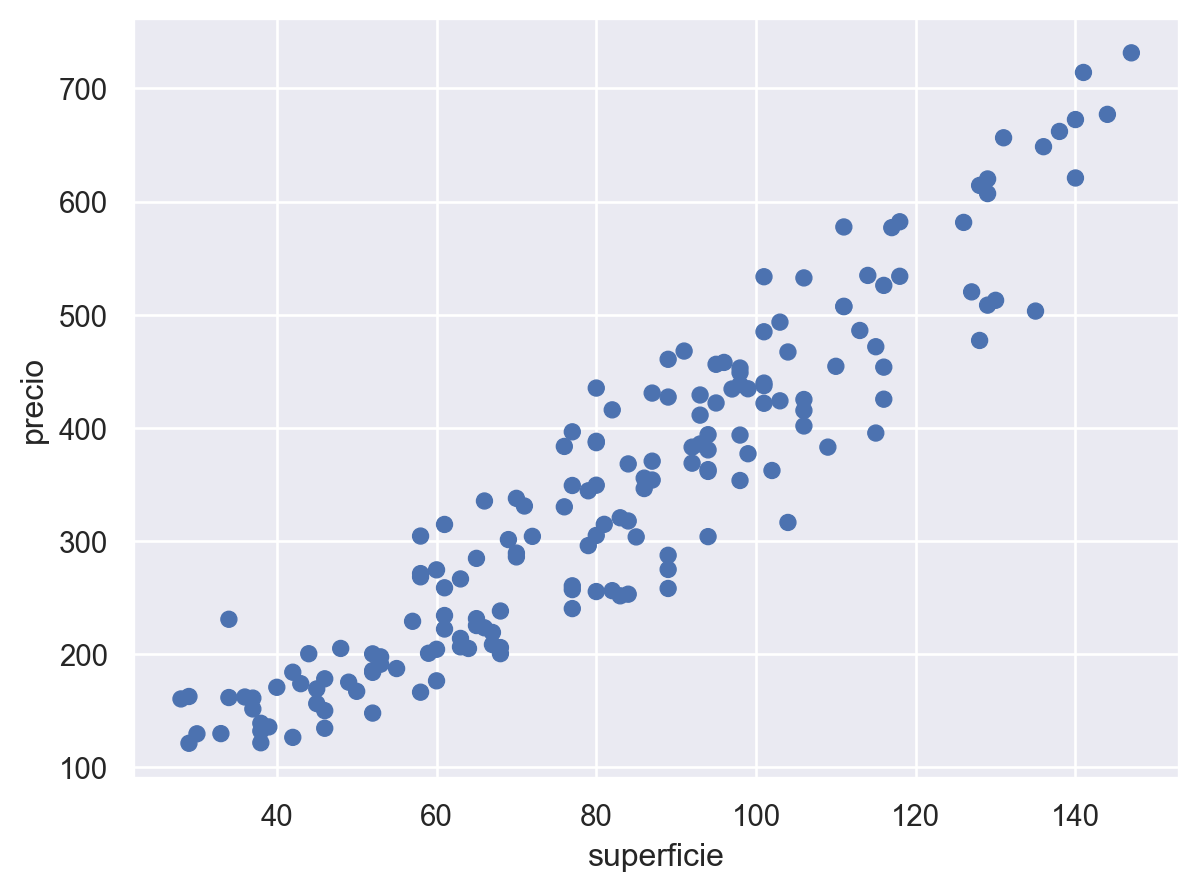

In [7]:
(
    so.Plot(
        data= datos,
        x = 'superficie',
        y = 'precio'
    )
    .add(
        so.Dot()
    )
)

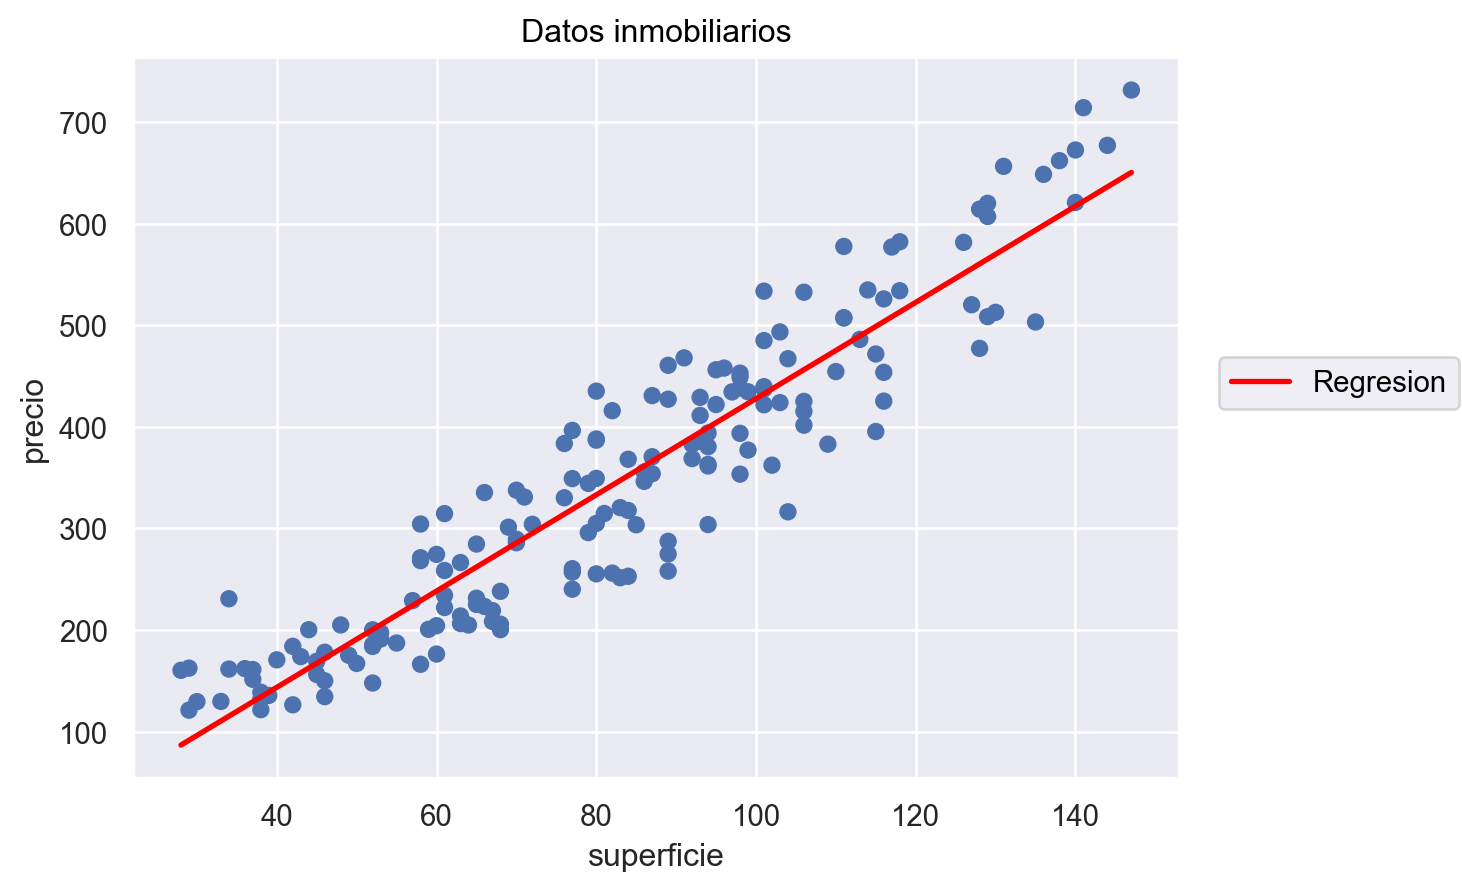

In [8]:
y, X = Formula('precio ~ superficie').get_model_matrix(datos)
model_2 = linear_model.LinearRegression(fit_intercept= False)
model_2.fit(X, y)

beta_0 = model_2.coef_[0][0]
beta_1 = model_2.coef_[0][1]

y_pred = model_2.predict(X)

(
    so.Plot(
        data= datos,
        x = 'superficie',
        y = 'precio'
    )
    .add(
        so.Dot()
    )
    .add(
        so.Line(color= 'red', linewidth= 2),
        so.PolyFit(1),
        y = y_pred.flatten(),
        label = 'Regresion'
    )
    .label(
        title = 'Datos inmobiliarios'
    )
)



In [9]:
print(f"Ordenada al origen (Beta 0): {beta_0:.3f}")
print(f"Pendiente (Beta 1): {beta_1:.3f}")

Ordenada al origen (Beta 0): -45.732
Pendiente (Beta 1): 4.736


Y = -45.732 + 4.736 X

In [10]:
def ecm(x, y, pendiente, o_origen):
    y_pred = pendiente*x + o_origen
    return np.mean((y - y_pred)**2)

def r_cuad(x, y, pendiente, o_origen):
    y_pred = pendiente*x + o_origen
    y_mean = np.mean(y)
    
    numerador = np.sum((y_pred - y_mean)**2)
    denominador = np.sum((y - y_mean)**2)
    
    return numerador / denominador
    

In [11]:
# (e) Calcular ECM y R2 con las funciones implementadas
ecm_calculado = ecm(datos['superficie'], datos['precio'], beta_1, beta_0)
r2_calculado = r_cuad(datos['superficie'], datos['precio'], beta_1, beta_0)

print(f"ECM (calculado a mano): {ecm_calculado:.2f}")
print(f"R^2 (calculado a mano): {r2_calculado:.4f}")

ECM (calculado a mano): 2630.93
R^2 (calculado a mano): 0.8762


In [12]:
np.sqrt(ecm_calculado)

np.float64(51.29259207668)

In [13]:
# (f) Calcular con Scikit-Learn
ecm_sklearn = mean_squared_error(datos['precio'], y_pred)
r2_sklearn = r2_score(datos['precio'], y_pred)

print(f"ECM (Scikit-Learn): {ecm_sklearn:.2f}")
print(f"R^2 (Scikit-Learn): {r2_sklearn:.4f}")

ECM (Scikit-Learn): 2630.93
R^2 (Scikit-Learn): 0.8762


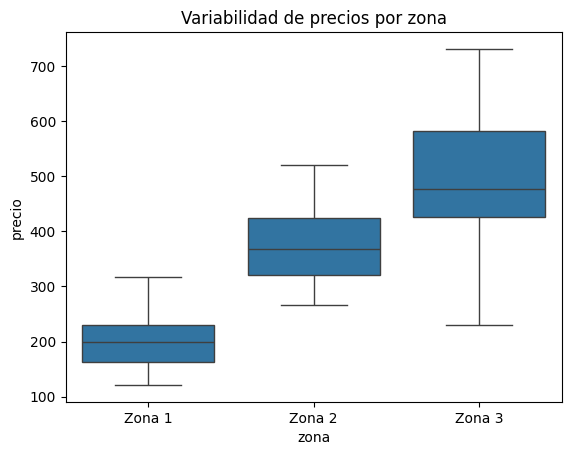

In [14]:
sns.boxplot(data=datos,
            x='zona',
            y='precio',
            order= sorted(datos['zona'])
)
plt.title("Variabilidad de precios por zona")
plt.show()

Para cada una de las zonas de la ciudad, calcular los coeficientes, el ECM y R2de la rectaque mejor aproxima a los datos

In [15]:
datos_zona1 = datos[datos['zona'] == 'Zona 1']

In [16]:
y, X = Formula('precio ~ superficie').get_model_matrix(datos_zona1)
modelo_zona1 = linear_model.LinearRegression(fit_intercept= False)
modelo_zona1.fit(X,y)

beta_0 = modelo_zona1.coef_[0][0]
beta_1 = modelo_zona1.coef_[0][1]

y_pred = modelo_zona1.predict(X)

print(beta_1, beta_0)
print(r2_score(datos_zona1['precio'], y_pred))
print(mean_squared_error(datos_zona1['precio'], y_pred))


2.442081388302122 58.85200024117237
0.855923919218176
331.2274677047097


In [17]:
datos_zona2 = datos[datos['zona'] == 'Zona 2']

y2, X2 = Formula('precio ~ superficie').get_model_matrix(datos_zona2)
modelo_zona2 = linear_model.LinearRegression(fit_intercept= False)
modelo_zona2.fit(X2,y2)

beta_0_2 = modelo_zona2.coef_[0][0]
beta_1_2 = modelo_zona2.coef_[0][1]

y_pred2 = modelo_zona2.predict(X2)

print(beta_1_2, beta_0_2)
print(r2_score(datos_zona2['precio'], y_pred2))
print(mean_squared_error(datos_zona2['precio'], y_pred2))

3.206278999112205 80.73010925558565
0.866027281146202
611.4955812522103


In [18]:
datos_zona3 = datos[datos['zona'] == 'Zona 3']

y3, X3 = Formula('precio ~ superficie').get_model_matrix(datos_zona3)
modelo_zona3 = linear_model.LinearRegression(fit_intercept= False)
modelo_zona3.fit(X3,y3)

beta_0_3 = modelo_zona3.coef_[0][0]
beta_1_3 = modelo_zona3.coef_[0][1]

y_pred3 = modelo_zona3.predict(X3)

print(beta_1_3, beta_0_3)
print(r2_score(datos_zona3['precio'], y_pred3))
print(mean_squared_error(datos_zona3['precio'], y_pred3))

4.560544269538952 24.966485225785146
0.9445652745220188
748.8800907160431


y = 4.56 x + 24.97

y = b_0 + b_1 x

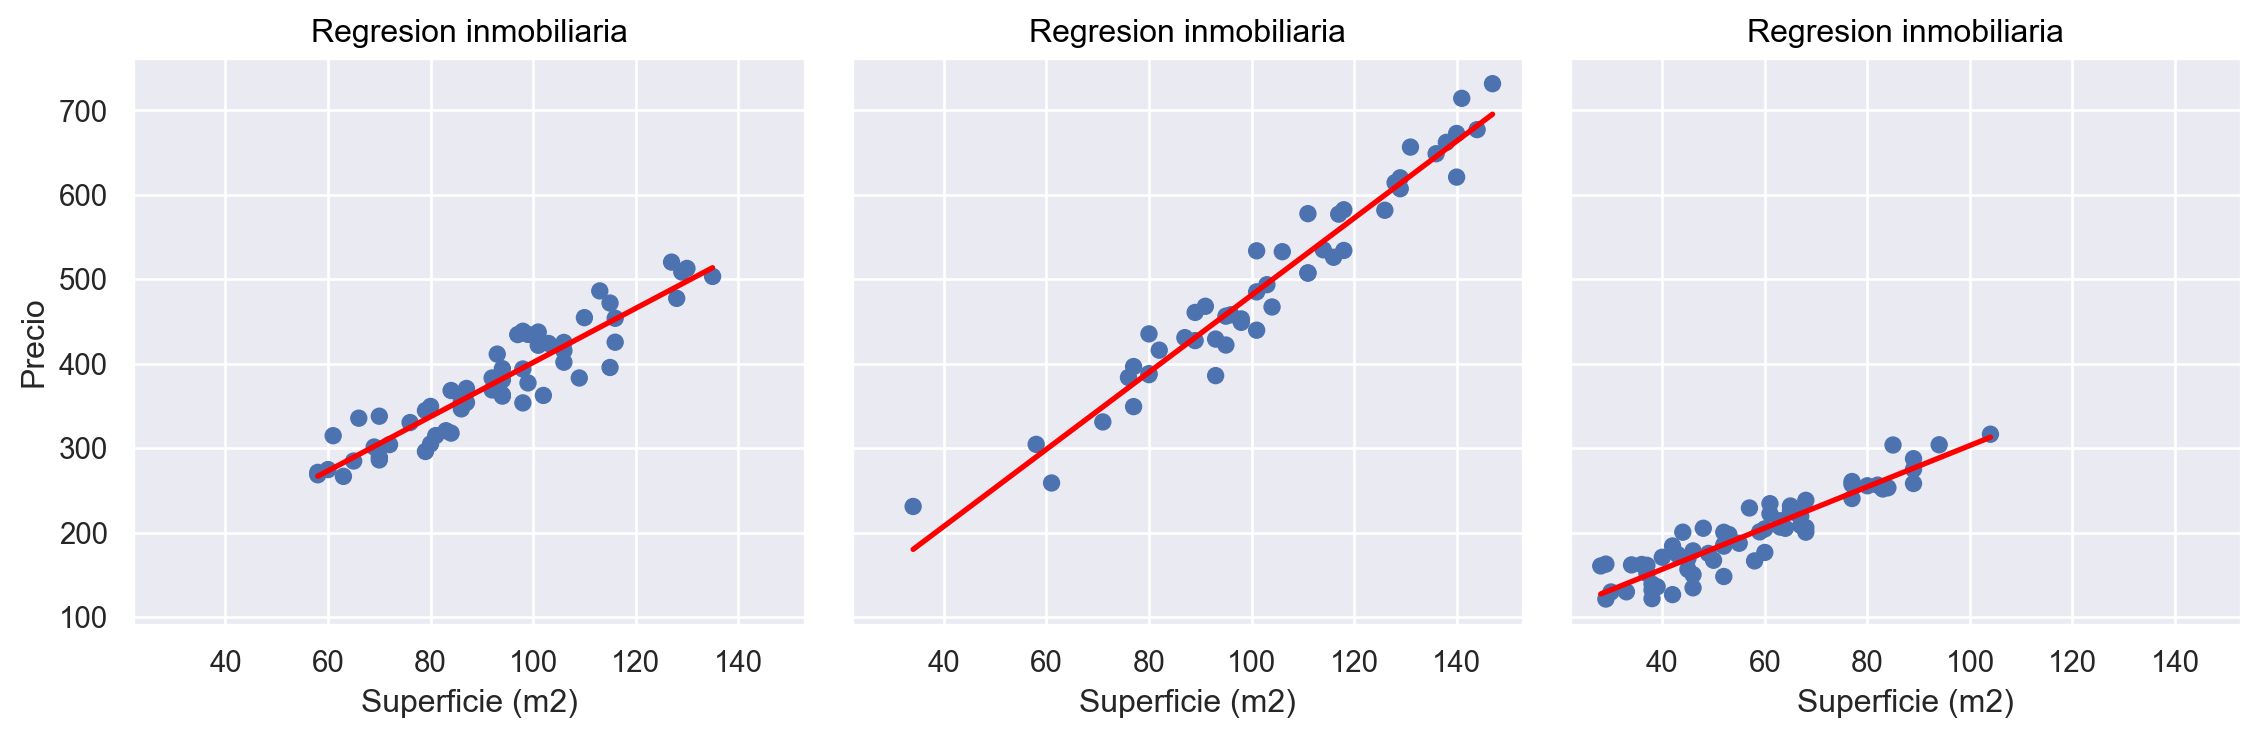

In [19]:
(
    so.Plot( data= datos,
            x = 'superficie',
            y = 'precio')
    .add(so.Dot())
    
    .add(so.Line(
        color='red',
        linewidth= 2),
         so.PolyFit(1))
    
    .facet('zona')
    
    .share(x= True, 
           y = True)
    .label(x = 'Superficie (m2)',
           y = 'Precio',
           title= 'Regresion inmobiliaria')
    .layout(
        size= (12,4))
)

Y = -45.732 + 4.736 X

In [24]:
print(-45.73 + 4.74*105, "millones")

451.97 millones


Zona 2

Y = 80.73 + 3.206X

In [22]:
print(beta_0_2 + beta_1_2*105, 'millones')

417.3894041623672 millones


In [25]:
print(beta_0_2 + beta_1_2*10, 'millones')

112.79289924670769 millones


# 4

In [38]:
tips = sns.load_dataset('tips')
promedio_bill = tips['total_bill'].mean()
tips['total_bill_centrado'] = tips['total_bill'] - promedio_bill

In [39]:
y, X = Formula('tip ~ total_bill_centrado').get_model_matrix(tips)
modelo = linear_model.LinearRegression(fit_intercept = False)
modelo.fit(X,y)
beta = modelo.coef_

beta_1 = beta[0][1]
beta_0 = beta[0][0]

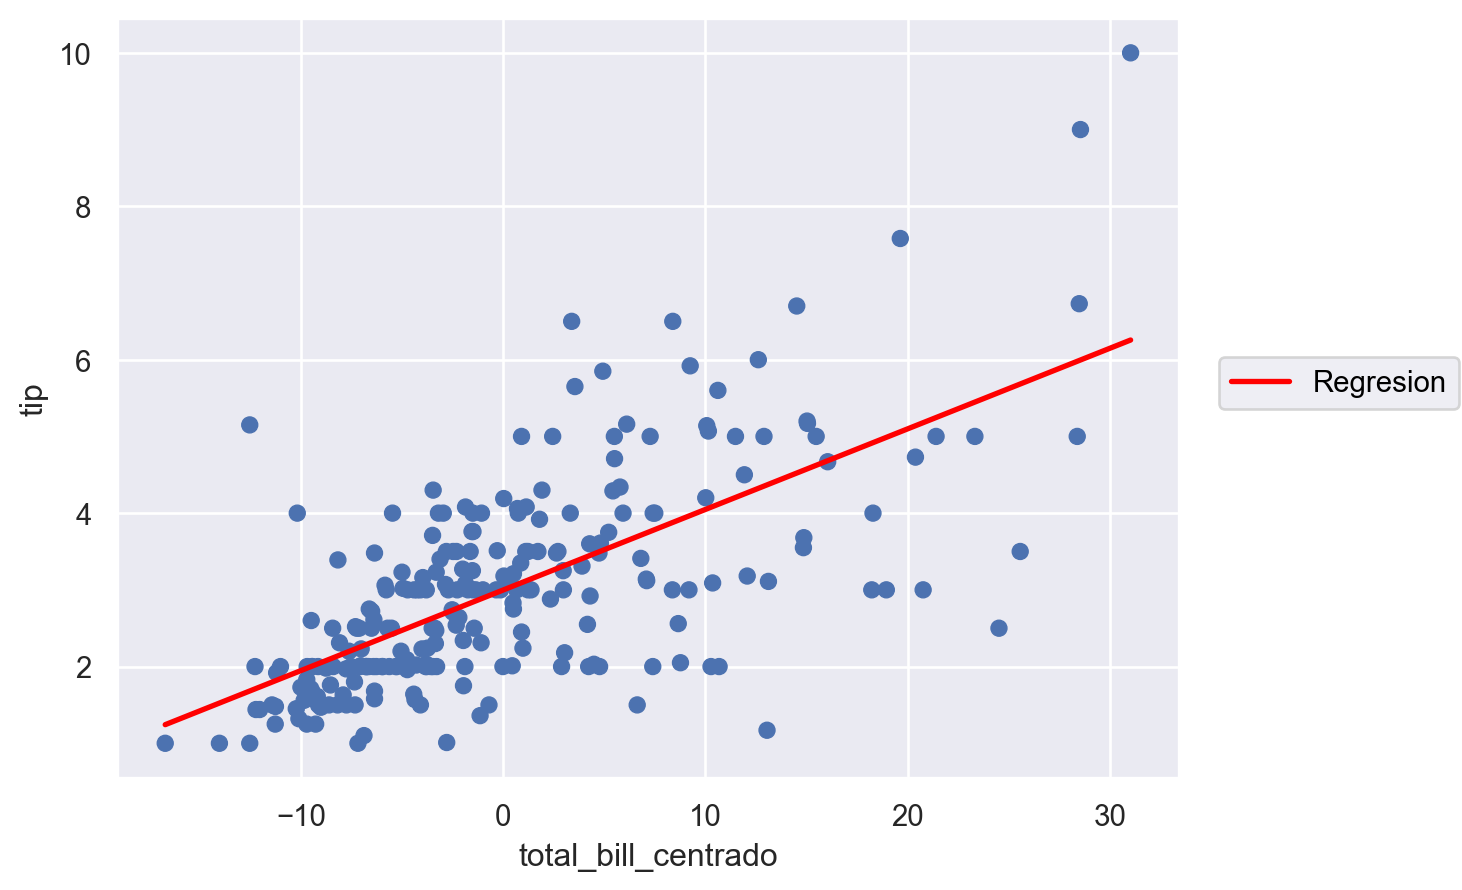

In [40]:
y_pred = modelo.predict(X)
(
    so.Plot(
        data = tips,
        x = 'total_bill_centrado',
        y = 'tip'
    )
    .add(
        so.Dot()
    )
    .add(
        so.Line(color = 'red', linewidth= 2),
        y = y_pred.flatten(),
        
        label = 'Regresion'
    )
)

In [42]:
print('beta 0:', beta_0)
print('beta 1:', beta_1)
print('promedio propina:', tips['tip'].mean())
print('diferencia entre beta 0 y promedio propina:', beta_0 - tips['tip'].mean())

beta 0: 2.99827868852459
beta 1: 0.10502451738435345
promedio propina: 2.99827868852459
diferencia entre beta 0 y promedio propina: 0.0


In [45]:
btc = pd.read_csv('bitcoin.csv')
btc.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [47]:
# Nos  aseguramos  que  pandas  interprete  la fecha  correctamente
btc['Date'] = pd.to_datetime(btc['Date'], format='%Y-%m-%d')
# Filtramos  el  dataset  en el  periodo  de  interes
btc_2021 = btc[(btc['Date']>"2021 -01 -01") & (btc['Date']<"2021 -07 -01")]

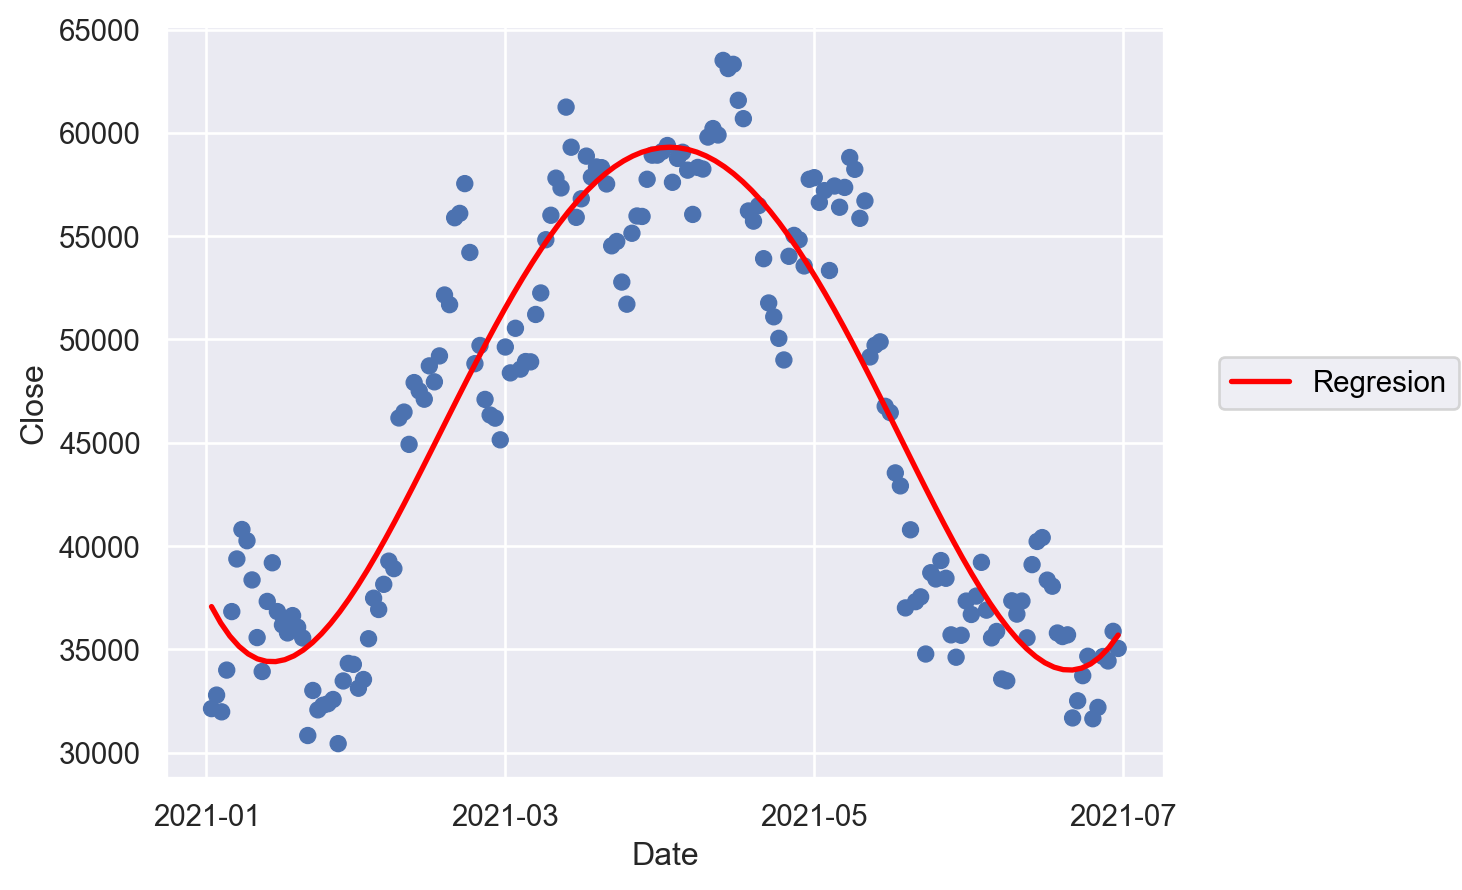

In [53]:
(
    so.Plot(
        data = btc_2021,
        x = 'Date',
        y = 'Close'
    )
    .add(
        so.Dot()
    )
    .add(
        so.Line(color = 'red', linewidth= 2),
        so.PolyFit(4),
        label = 'Regresion'
    )
)

In [104]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [105]:
health_japan = healthexp[healthexp['Country'] == 'Japan']
health_japan.head()

,Year,Country,Spending_USD,Life_Expectancy
3,1970,Japan,150.437,72.0
8,1971,Japan,163.854,72.9
11,1972,Japan,185.390,73.2
14,1973,Japan,205.778,73.4
17,1974,Japan,242.018,73.7


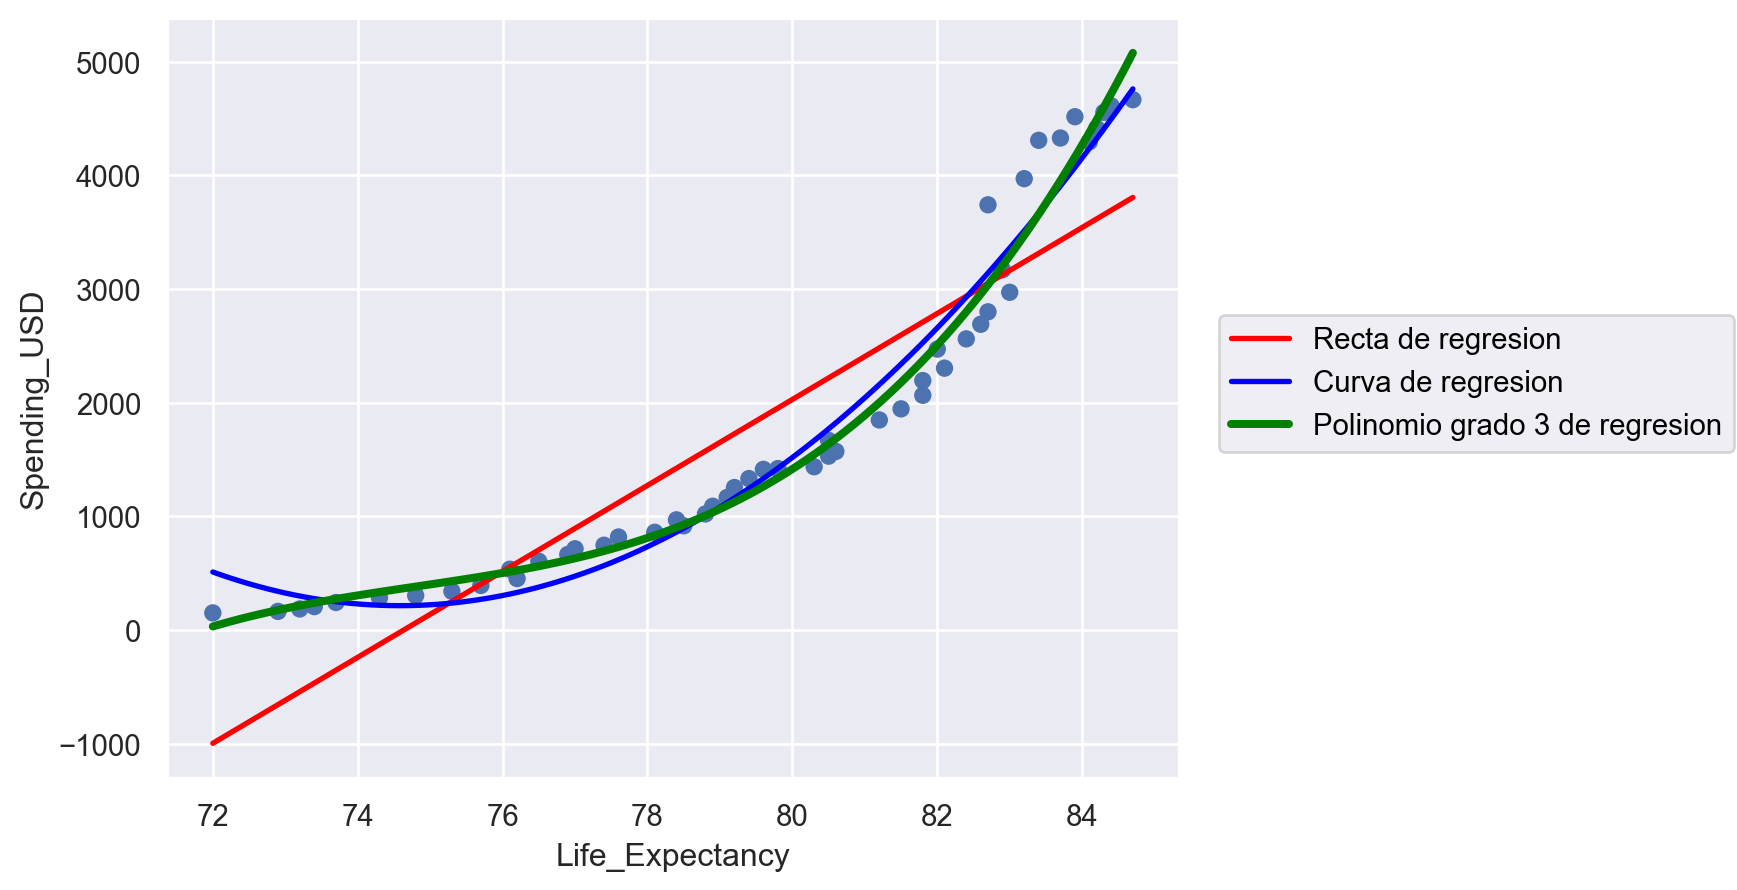

In [106]:
(
    so.Plot(
        data = health_japan,
        x = 'Life_Expectancy',
        y = 'Spending_USD'
    )
    .add(
        so.Dot()
    )
    .add(
        so.Line(color = 'red', linewidth = 2),
        so.PolyFit(1),
        label = 'Recta de regresion'
    )
    .add(
        so.Line(color = 'blue', linewidth = 2),
        so.PolyFit(2),  
        label = 'Curva de regresion'
    )
    .add(
        so.Line(color = 'green', linewidth = 3),
        so.PolyFit(3),  
        label = 'Polinomio grado 3 de regresion'
    )
)

In [107]:
y, X = Formula('Life_Expectancy ~ poly(Spending_USD, degree=3, raw = True)').get_model_matrix(health_japan)

modelo = linear_model.LinearRegression(fit_intercept = False)
modelo.fit(X, y)
beta = modelo.coef_
print('beta_0:', beta[0][0])
print('beta_1:', beta[0][1])
print('beta_2:', beta[0][2])
print('beta_3:', beta[0][3])


beta_0: 71.84403254427325
beta_1: 0.009097662205084109
beta_2: -2.684173320369204e-06
beta_3: 2.8216848475201683e-10


$Y = 1860.26 + 9484.56X + 3765.61 X^2 + 1059.63X^3$

In [108]:
y_pred = modelo.predict(X)

In [109]:
print('ecm: ', mean_squared_error(y, y_pred))
print('r2: ', r2_score(y, y_pred)*100, '%')

ecm:  0.10758286138707461
r2:  99.12790933475435 %


In [110]:
def polinomio_gr_3(x, beta):
    return beta[0][0] + beta[0][1]*x + beta[0][2]*x**2 + beta[0][3]*x**3

print(polinomio_gr_3(5000, beta))
print(f'Expectativa de vida con USD 5000: {polinomio_gr_3(5000, beta):.2f} años')



85.49907115446578
Expectativa de vida con USD 5000: 85.50 años


c:\Users\s94-e\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\_stats\regression.py:30: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x, y, self.order)


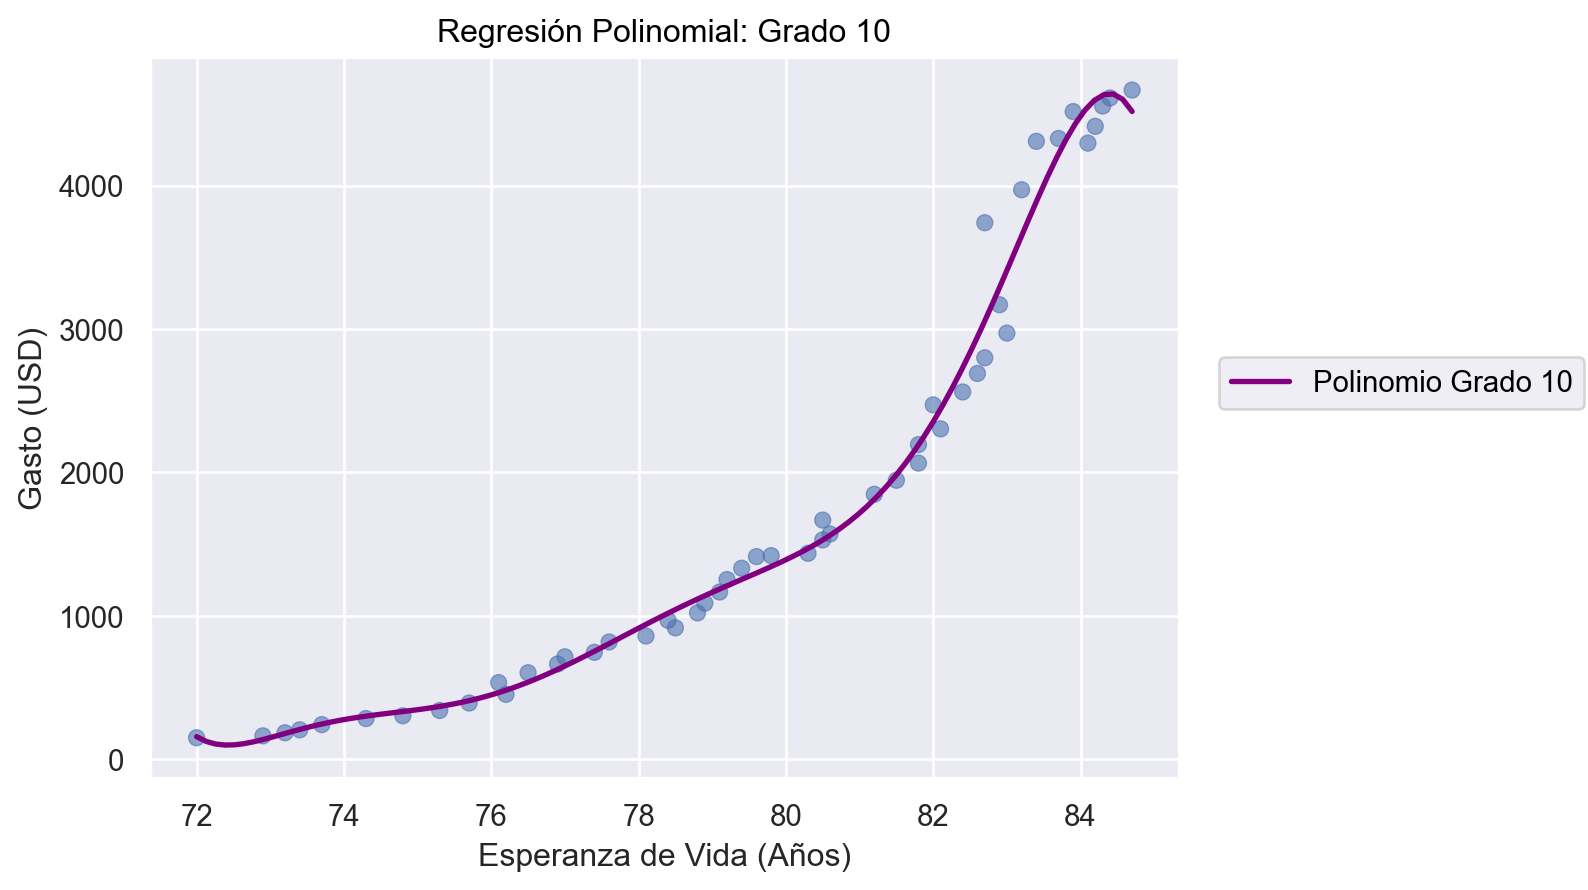

In [112]:

(
    so.Plot(data=health_japan, x='Life_Expectancy', y='Spending_USD')
    .add(so.Dot(alpha=0.6))
    .add(
        so.Line(color='purple', linewidth=2),
        so.PolyFit(order=10),
        label='Polinomio Grado 10'
    )
    .label(
        title="Regresión Polinomial: Grado 10", 
        x="Esperanza de Vida (Años)", 
        y="Gasto (USD)"
    )
)

No es conveniente, riesgo de Overfitting.

# 6

In [114]:
mpgset = sns.load_dataset('mpg')
mpgset.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


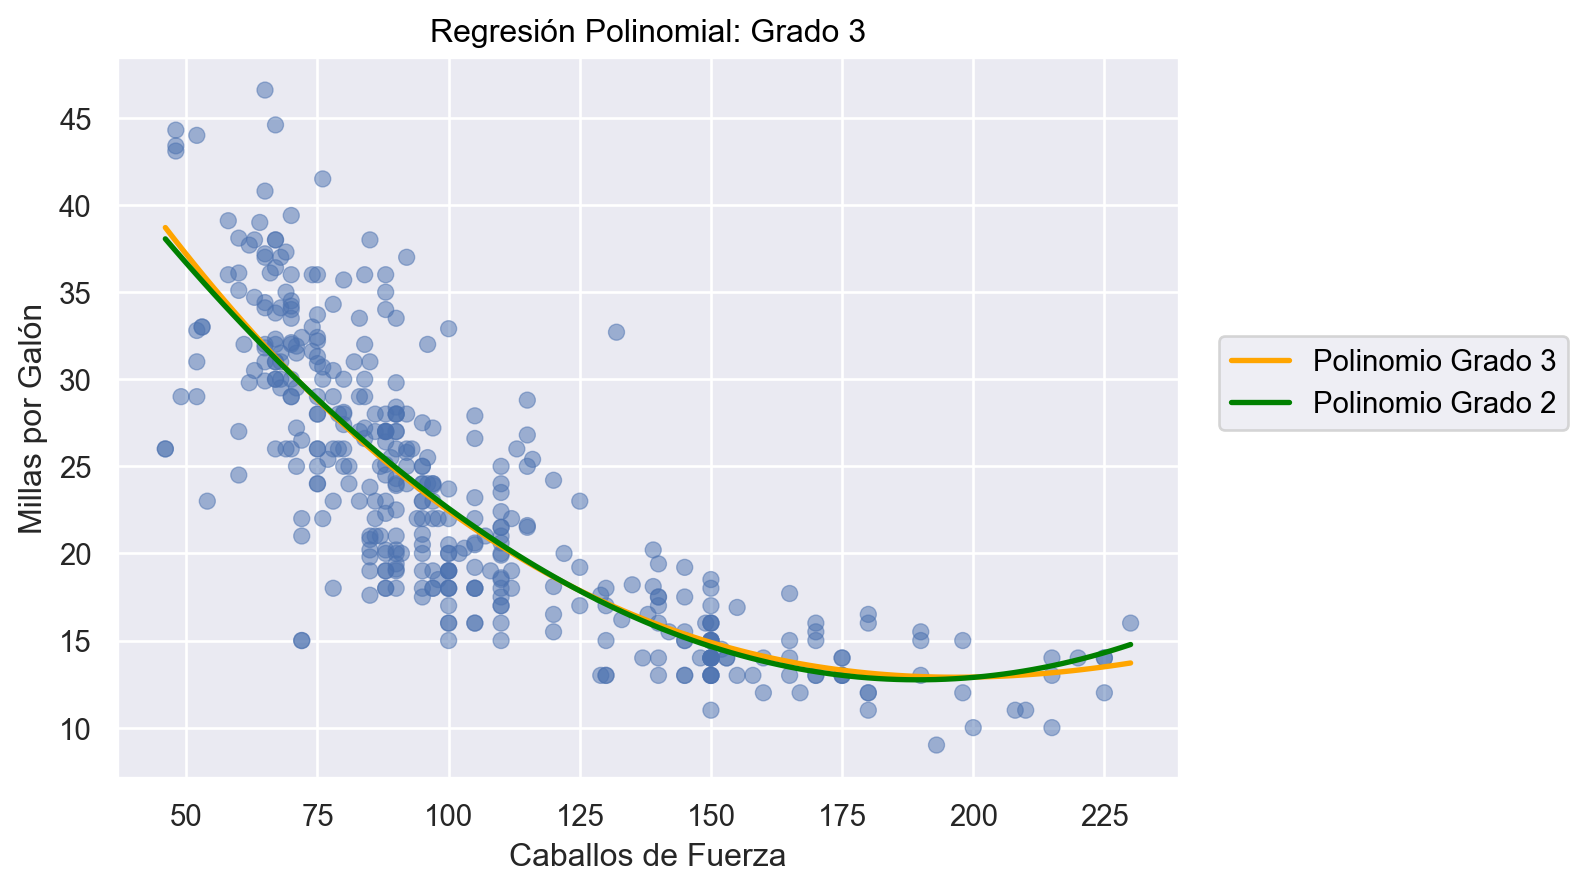

In [135]:
(
    so.Plot(
        data = mpgset,
        x = 'horsepower',
        y = 'mpg'
    )
    .add(so.Dot(
        alpha= 0.5
    ))
    .add(
        so.Line(color='orange', linewidth=2),
        so.PolyFit(order=3),
        label='Polinomio Grado 3'
    )
    .add(
        so.Line(color='green', linewidth=2),
        so.PolyFit(order=2),
        label='Polinomio Grado 2'
    )
    .label(
        title="Regresión Polinomial: Grado 3", 
        x="Caballos de Fuerza", 
        y="Millas por Galón")
)

In [143]:
y, X = Formula('mpg ~ poly(horsepower, degree=2, raw=True)').get_model_matrix(mpgset)

modelo = linear_model.LinearRegression(fit_intercept = False)
modelo.fit(X, y)
beta = modelo.coef_
y_pred = modelo.predict(X)
print('beta_0:', beta[0][0])
print('beta_1:', beta[0][1])
print('beta_2:', beta[0][2])
print('ecm: ', mean_squared_error(y, y_pred))
print('r2: ', r2_score(y, y_pred)*100, '%')

beta_0: 56.90009970211659
beta_1: -0.4661896299473799
beta_2: 0.0012305361007739866
ecm:  18.98476890761722
r2:  68.75590305127517 %


In [144]:
y, X = Formula('mpg ~ np.exp(-horsepower/100)').get_model_matrix(mpgset)
modelo = linear_model.LinearRegression(fit_intercept = False)
modelo.fit(X, y)
beta = modelo.coef_
y_pred = modelo.predict(X)
print('beta_0:', beta[0][0])
print('beta_1:', beta[0][1])
print('ecm: ', mean_squared_error(y, y_pred))
print('r2: ', r2_score(y, y_pred)*100, '%')

beta_0: 3.4234970192127507
beta_1: 53.3658764776985
ecm:  19.735915956356656
r2:  67.51970621749925 %


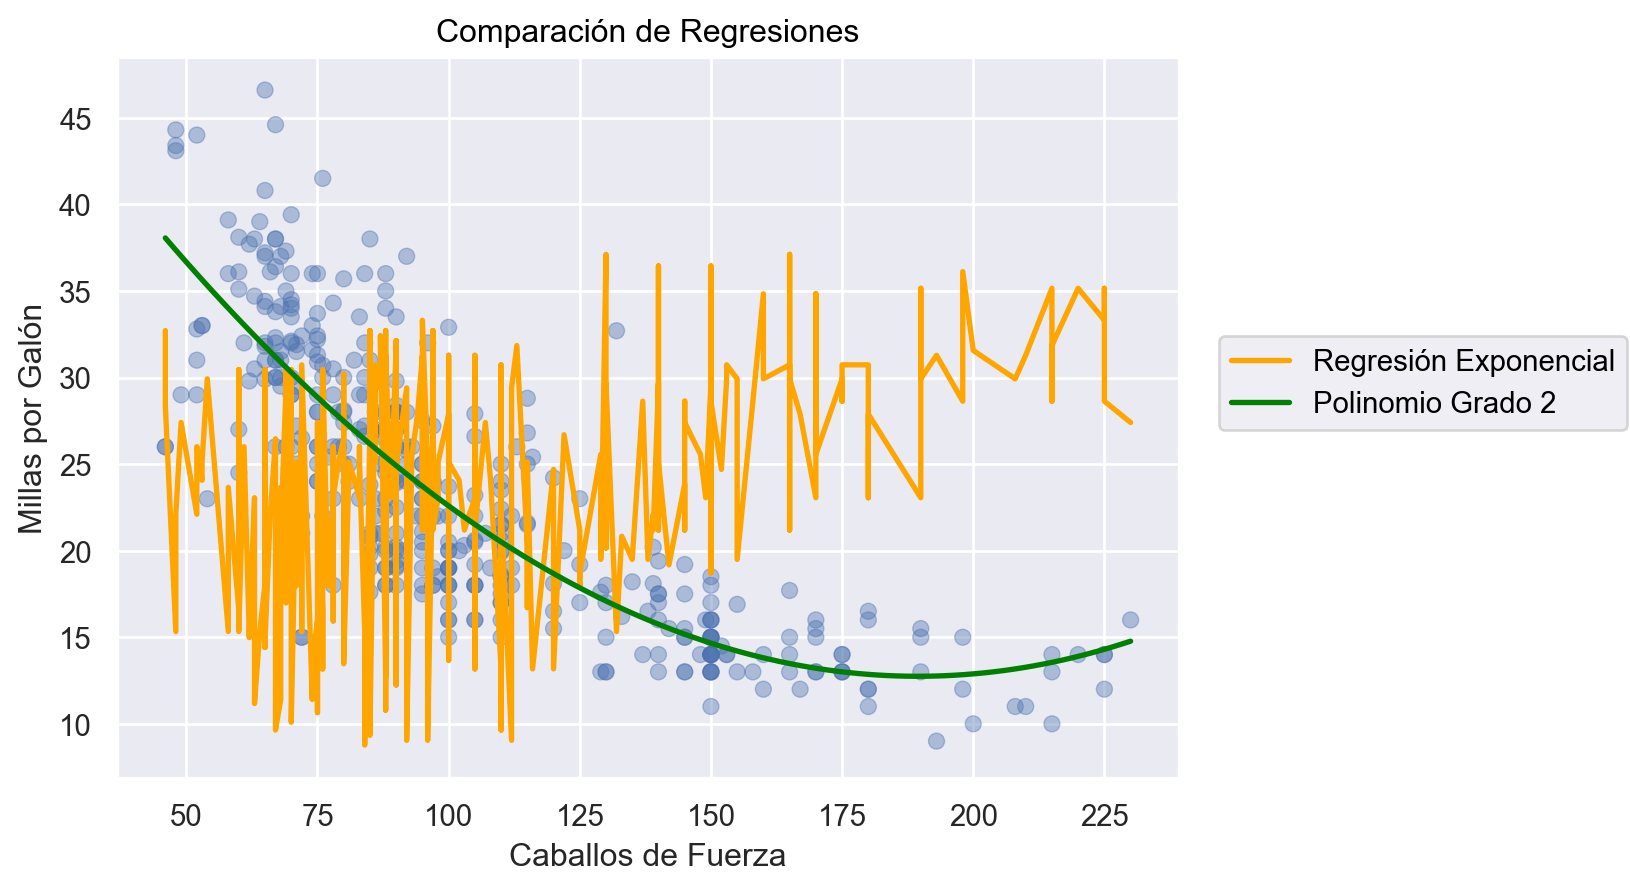

In [148]:
# 1. Limpiamos nulos Y ORDENAMOS el dataset por caballos de fuerza
mpgset = mpgset.dropna(subset=['horsepower', 'mpg']).sort_values('horsepower').copy()

# 2. Volvemos a generar la regresión exponencial con los datos ya ordenados
y, X = Formula('mpg ~ np.exp(-horsepower/100)').get_model_matrix(mpgset)
modelo = linear_model.LinearRegression(fit_intercept=False)
modelo.fit(X, y)
y_pred = modelo.predict(X)

# 3. Graficamos (ahora las líneas van a quedar perfectamente suaves)
(
    so.Plot(
        data = mpgset,
        x = 'horsepower',
        y = 'mpg'
    )
    .add(so.Dot(alpha=0.4))
    .add(
        so.Line(color='orange', linewidth=2),
        y = y_pred.flatten(), # Aplastamos el array para evitar el error de dimensiones
        label='Regresión Exponencial'
    )
    .add(
        so.Line(color='green', linewidth=2),
        so.PolyFit(order=2),
        label='Polinomio Grado 2'
    )
    .label(
        title="Comparación de Regresiones", 
        x="Caballos de Fuerza", 
        y="Millas por Galón"
    )
)